<a href="https://colab.research.google.com/github/mao-debug/Auto/blob/main/vehicle_lpr_ignite.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Vehicle Detection & License Plate Recognition Tutorial


In this notebook, we’ll build a computer vision pipeline that can:

1. Detect vehicles (cars, buses, trucks, motorcycles) in images.

2. Detect license plates inside those vehicles.

3. Recognize the text on each plate.

**Object detection** teaches us how models can localize multiple objects by drawing bounding boxes, not just classify a whole image.

**OCR (Optical Character Recognition)** shows how to interpret sequences of characters from image pixels.

Together, this is a classic real-world task called **Automatic License Plate Recognition (ALPR)**, used in tolling, parking, and traffic monitoring.

# What inputs & outputs will look like

**Input:**
A natural photo (e.g. cars on a street).

**Intermediate output:**
YOLO draws boxes around each vehicle and plate.

**Final output:**
Each plate bounding box is cropped, sent through OCR, and labeled with the recognized text.


## 1) Environment Setup
In this section, we install the necessary Python libraries.

We also check whether a GPU is available. GPUs speed up training massively compared to CPUs because they can run many matrix multiplications in parallel. You can enable GPU on Colab by clicking Runtime > Change Runtime Type > (select a GPU, e.g. T4 GPU). We can also just use the CPU if the GPU is not available.

In [ ]:

%pip -q install --upgrade pip
%pip -q install ultralytics==8.3.34 openimages opencv-python matplotlib pillow albumentations tqdm
%pip -q install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

import os, sys, random, shutil
from pathlib import Path
import numpy as np, cv2, matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont, ImageFilter
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

print("Torch:", torch.__version__, "CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 23.9 MB/s eta 0:00:00
Torch: 2.8.0+cu126 CUDA available: True


device(type='cuda')

## 2) Project Structure
In this section we will set up our project directories. These include folders for raw image and annotation data (from Open Images), processed datasets (in YOLO format), and trained model outputs (under runs/).


In [ ]:

project_root = Path("vehicle_lp_project")
for p in [
    project_root / "data" / "openimages",
    project_root / "data" / "yolo_vehicle",
    project_root / "data" / "yolo_plate",
    project_root / "runs"
]:
    p.mkdir(parents=True, exist_ok=True)
print("Project root:", project_root.resolve())


Project root: /content/vehicle_lp_project


## 3) Download Open Images (YOLO/Darknet format)

Here we download a small subset of the Open Images dataset. Specifically, we fetch images of vehicles (Car, Bus, Truck, Motorcycle) as well as license plates.

Each image comes with YOLO label files, which contain bounding box coordinates and class IDs.

In practice, you’d download thousands of images for each class. Here we use fewer (300) for a quicker demo. If you want to improve model performance, you can run this notebook again and increase the `limit` in the `download_dataset` function call.

In [ ]:

from openimages.download import download_dataset

oi_base = project_root / "data" / "openimages"
vehicle_classes = ["Car","Bus","Truck","Motorcycle"]
plate_classes   = ["Vehicle registration plate"]
labels = vehicle_classes + plate_classes

download_dataset(str(oi_base), labels, annotation_format="darknet", limit=300)
print("Open Images download complete at:", oi_base)


100%|██████████| 300/300 [00:00<00:00, 2589.61it/s]


Open Images download complete at: vehicle_lp_project/data/openimages


## 4) Consolidate YOLO labels into training and validation sets

To train a detection model, YOLO expects data in a particular format:

*   Images under **images/train** and **images/val**
*   Matching label files under **labels/train** and **labels/val**
*   A YAML config file that lists the dataset paths and the class names



We also split the data into a **training** and **validation** set. The training set is used to fit the model parameters, and the validation set is a smaller subset we set aside to measure how well the model generalizes.

The split ratio (e.g. 90/10) helps detect **overfitting**: if training accuracy rises but validation accuracy does not, the model is memorizing instead of generalizing.

In [ ]:

import shutil, random
from pathlib import Path

veh_out = project_root / "data" / "yolo_vehicle"
plt_out = project_root / "data" / "yolo_plate"
for p in [veh_out/"images/train", veh_out/"images/val", veh_out/"labels/train", veh_out/"labels/val",
          plt_out/"images/train", plt_out/"images/val", plt_out/"labels/train", plt_out/"labels/val"]:
    p.mkdir(parents=True, exist_ok=True)

def find_image_for_label(label_path: Path):
    preferred = [".jpg",".jpeg",".png",".bmp",".webp"]
    stem = label_path.stem
    for ext in preferred:
      # If parent is 'darknet', class_dir = parent.parent; else class_dir = parent
      class_dir = label_path.parent
      if class_dir.name.lower() == "darknet":
          class_dir = class_dir.parent
      images_dir = class_dir / "images"
      if images_dir.exists():
          for ext in preferred:
              cand = images_dir / f"{stem}{ext}"
              if cand.exists():
                  return cand
    return None

veh_map = {name:i for i,name in enumerate(["Car","Bus","Truck","Motorcycle"])}
plt_map = {"license_plate": 0}
veh_boxes, plt_boxes = {}, {}

def add_boxes(target, img_path, lines):
    target.setdefault(img_path, []).extend(lines)

all_lbls = list((oi_base).rglob("*.txt"))
print(all_lbls)
num_parsed = 0
for lbl in all_lbls:
    parts_lower = [p.name.lower() for p in lbl.parents]
    cls_name = None
    for cname in ["Car","Bus","Truck","Motorcycle","Vehicle registration plate"]:
        if cname.lower() in parts_lower:
            cls_name = cname
            break
    if cls_name is None:
        continue
    img_path = find_image_for_label(lbl)
    if not img_path or not img_path.exists():
        continue
    with open(lbl,"r") as f:
        raw = [ln.strip() for ln in f if ln.strip()]
    if not raw:
        continue
    remapped = []
    if cls_name in veh_map:
        cls_id = veh_map[cls_name]
        for ln in raw:
            parts = ln.split()
            if len(parts) != 5: continue
            cx,cy,w,h = parts[1:]
            remapped.append(f"{cls_id} {cx} {cy} {w} {h}")
        add_boxes(veh_boxes, img_path, remapped)
    elif cls_name == "Vehicle registration plate":
        cls_id = 0
        for ln in raw:
            parts = ln.split()
            if len(parts) != 5: continue
            cx,cy,w,h = parts[1:]
            remapped.append(f"{cls_id} {cx} {cy} {w} {h}")
        add_boxes(plt_boxes, img_path, remapped)
    num_parsed += 1

print(f"Parsed label files from {num_parsed} class folders.")
print(f"Vehicle images collected: {len(veh_boxes)}, Plate images collected: {len(plt_boxes)}")

def write_split(out_root: Path, img_to_boxes: dict, split_ratio=0.1):
    imgs = list(img_to_boxes.keys())
    random.shuffle(imgs)
    n_val = max(1, int(len(imgs)*split_ratio))
    val_set = set(imgs[:n_val])
    for img in imgs:
        split = "val" if img in val_set else "train"
        dst_img = out_root / f"images/{split}/{img.name}"
        dst_lbl = out_root / f"labels/{split}/{img.stem}.txt"
        if not dst_img.exists():
            try:
                shutil.copy2(img, dst_img)
            except Exception:
                continue
        lines = list(dict.fromkeys(img_to_boxes[img]))
        with open(dst_lbl,"w") as f:
            f.write("\n".join(lines))

# Split data into train and validation
# split_ratio defines validation set percentage (10% validation, 90% train)
# Play with the ratio to see how it changes the model performance!
write_split(veh_out, veh_boxes, split_ratio=0.1)
write_split(plt_out, plt_boxes, split_ratio=0.1)

veh_yaml = f"""# Auto-generated
path: {veh_out.resolve()}
train: images/train
val: images/val
names: ['Car','Bus','Truck','Motorcycle']
"""
plt_yaml = f"""# Auto-generated
path: {plt_out.resolve()}
train: images/train
val: images/val
names: ['license_plate']
"""
(veh_out/"dataset.yaml").write_text(veh_yaml)
(plt_out/"dataset.yaml").write_text(plt_yaml)

print("Wrote:", veh_out/"dataset.yaml")
print("Wrote:", plt_out/"dataset.yaml")


[PosixPath('vehicle_lp_project/data/openimages/darknet_obj_names.txt'), PosixPath('vehicle_lp_project/data/openimages/truck/darknet/04545e5c9d284a78.txt'), PosixPath('vehicle_lp_project/data/openimages/truck/darknet/0365a4a6131ac0c7.txt'), PosixPath('vehicle_lp_project/data/openimages/truck/darknet/0a735fa70b89927b.txt'), PosixPath('vehicle_lp_project/data/openimages/truck/darknet/00e575172c598e71.txt'), PosixPath('vehicle_lp_project/data/openimages/truck/darknet/0501f147bcb10f8e.txt'), PosixPath('vehicle_lp_project/data/openimages/truck/darknet/016ac025b012aac8.txt'), PosixPath('vehicle_lp_project/data/openimages/truck/darknet/00072b81abc72d21.txt'), PosixPath('vehicle_lp_project/data/openimages/truck/darknet/0181c8fe6cc0b2c8.txt'), PosixPath('vehicle_lp_project/data/openimages/truck/darknet/0440ba7a91e59ce5.txt'), PosixPath('vehicle_lp_project/data/openimages/truck/darknet/07cee130a37dd85a.txt'), PosixPath('vehicle_lp_project/data/openimages/truck/darknet/09c176fb3413558e.txt'), Posi


**Class balance** matters too: if one class (say Car) dominates, the model may learn to always predict that class. Balancing the dataset or using class weighting helps ensure fairness across categories.

In [ ]:
# --- Check class balance in datasets ---
from collections import Counter

def count_labels(label_dir, class_names):
    counts = Counter()
    for lbl in label_dir.glob("*.txt"):
        with open(lbl) as f:
            for line in f:
                cls_id = int(line.split()[0])
                counts[cls_id] += 1
    total = sum(counts.values())
    print(f"Total labels in {label_dir}: {total}")
    for i, name in enumerate(class_names):
        print(f"  {name:12s}: {counts[i]} ({counts[i]/total:.1%} of dataset)")

print("== Vehicle dataset ==")
count_labels(veh_out/"labels/train", ["Car","Bus","Truck","Motorcycle"])
count_labels(veh_out/"labels/val", ["Car","Bus","Truck","Motorcycle"])

print("\n== Plate dataset ==")
count_labels(plt_out/"labels/train", ["license_plate"])
count_labels(plt_out/"labels/val", ["license_plate"])

== Vehicle dataset ==
Total labels in vehicle_lp_project/data/yolo_vehicle/labels/train: 1275
  Car         : 410 (32.2% of dataset)
  Bus         : 284 (22.3% of dataset)
  Truck       : 304 (23.8% of dataset)
  Motorcycle  : 277 (21.7% of dataset)
Total labels in vehicle_lp_project/data/yolo_vehicle/labels/val: 146
  Car         : 40 (27.4% of dataset)
  Bus         : 24 (16.4% of dataset)
  Truck       : 39 (26.7% of dataset)
  Motorcycle  : 43 (29.5% of dataset)

== Plate dataset ==
Total labels in vehicle_lp_project/data/yolo_plate/labels/train: 347
  license_plate: 347 (100.0% of dataset)
Total labels in vehicle_lp_project/data/yolo_plate/labels/val: 43
  license_plate: 43 (100.0% of dataset)


## 5) Train YOLO Detectors
Now we train two detectors:

1. **Vehicle detector:** recognizes cars, buses, trucks, motorcycles.

2. **License plate detector:** finds license plates inside vehicle regions.


Here are some ML concepts that are useful for understanding what's happening during this process:

* **Epoch:** one full pass through the training set. After each epoch, the model has “seen” all training examples once.

* **Batch size:** how many images are processed before the model updates its weights. Larger batches smooth out gradient estimates, but need more memory.

* **Loss function:** a measure of how far predictions are from the ground truth. For detection, YOLO’s loss combines classification loss, objectness loss, and bounding box regression loss. Training seeks to minimize this loss.

* **Optimizer:** adjusts model weights to minimize the loss function.

We train only for a few epochs here. Real experiments typically need tens to hundreds of epochs. Try increasing the number of epochs to see how the loss changes during training!

In [ ]:

from ultralytics import YOLO

vehicle_data_yaml = str((project_root/"data"/"yolo_vehicle"/"dataset.yaml").resolve())

vehicle_model = YOLO("yolo11n.pt")

vehicle_results = vehicle_model.train(
    data=vehicle_data_yaml, epochs=3, imgsz=640, batch=16,
    project=str(project_root/"runs"), name="vehicle_det_yolo11n", exist_ok=True
)



Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 5.35M/5.35M [00:00<00:00, 56.9MB/s]


New https://pypi.org/project/ultralytics/8.3.202 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.34 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=/content/vehicle_lp_project/data/yolo_vehicle/dataset.yaml, epochs=3, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=vehicle_lp_project/runs, name=vehicle_det_yolo11n, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classe

100%|██████████| 755k/755k [00:00<00:00, 18.5MB/s]


Overriding model.yaml nc=80 with nc=4

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      6640  ultralytics.nn.modules.block.C3k2            [32, 64, 1, False, 0.25]      
  3                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
  4                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  5                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  6                  -1  1     87040  ultralytics.nn.modules.block.C3k2            [128, 128, 1, True]           
  7                  -1  1    295424  ultralytics

...

        3/3      2.38G     0.9146       1.72       1.25         22        640: 100%|██████████| 67/67 [00:22<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:01<00:00,  2.73it/s]

                   all        120        146      0.578      0.683      0.697      0.527



3 epochs completed in 0.031 hours.
Optimizer stripped from vehicle_lp_project/runs/vehicle_det_yolo11n/weights/last.pt, 5.5MB
Optimizer stripped from vehicle_lp_project/runs/vehicle_det_yolo11n/weights/best.pt, 5.5MB

Validating vehicle_lp_project/runs/vehicle_det_yolo11n/weights/best.pt...
Ultralytics 8.3.34 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 238 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:02<00:00,  1.93it/s]


                   all        120        146      0.576      0.684      0.697      0.526
                   Car         28         40      0.436        0.6      0.531      0.409
                   Bus         23         24      0.539      0.917      0.886      0.789
                 Truck         33         39      0.698      0.474       0.63      0.461
            Motorcycle         36         43      0.632      0.744      0.741      0.446
Speed: 0.2ms preprocess, 3.6ms inference, 0.0ms loss, 5.1ms postprocess per image
Results saved to vehicle_lp_project/runs/vehicle_det_yolo11n


In [ ]:
plate_data_yaml   = str((project_root/"data"/"yolo_plate"/"dataset.yaml").resolve())

plate_model   = YOLO("yolo11n.pt")

plate_results = plate_model.train(
    data=plate_data_yaml, epochs=30, imgsz=640, batch=16,
    project=str(project_root/"runs"), name="plate_det_yolo11n", exist_ok=True
)

New https://pypi.org/project/ultralytics/8.3.202 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.34 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=/content/vehicle_lp_project/data/yolo_plate/dataset.yaml, epochs=30, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=vehicle_lp_project/runs, name=plate_det_yolo11n, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=N

train: Scanning /content/vehicle_lp_project/data/yolo_plate/labels/train... 270 images, 0 backgrounds, 0 corrupt: 100%|██████████| 270/270 [00:00<00:00, 2469.01it/s]

train: New cache created: /content/vehicle_lp_project/data/yolo_plate/labels/train.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



val: Scanning /content/vehicle_lp_project/data/yolo_plate/labels/val... 30 images, 0 backgrounds, 0 corrupt: 100%|██████████| 30/30 [00:00<00:00, 1110.29it/s]

val: New cache created: /content/vehicle_lp_project/data/yolo_plate/labels/val.cache


...

      30/30      2.42G      1.039     0.9045     0.9613         18        640: 100%|██████████| 17/17 [00:04<00:00,  3.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  2.23it/s]

                   all         30         43       0.82      0.581       0.66      0.388



30 epochs completed in 0.058 hours.
Optimizer stripped from vehicle_lp_project/runs/plate_det_yolo11n/weights/last.pt, 5.5MB
Optimizer stripped from vehicle_lp_project/runs/plate_det_yolo11n/weights/best.pt, 5.5MB

Validating vehicle_lp_project/runs/plate_det_yolo11n/weights/best.pt...
Ultralytics 8.3.34 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 238 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  4.30it/s]


                   all         30         43       0.82      0.581      0.661      0.391
Speed: 0.2ms preprocess, 2.4ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to vehicle_lp_project/runs/plate_det_yolo11n


## 6) Vehicle Detection Quick Evaluation & Visualization

After training, we can visualize predictions. This helps answer:

* Are bounding boxes roughly aligned with objects?

* Are class predictions correct?

* Do confidence scores (0–1) reflect our intuition?

Quantitatively, YOLO reports **mAP (mean Average Precision)**, which summarizes detection accuracy across classes. Here we focus on qualitative checks to quickly spot obvious issues.

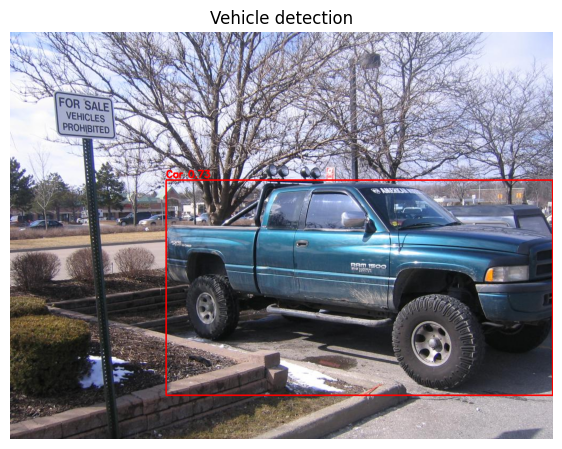

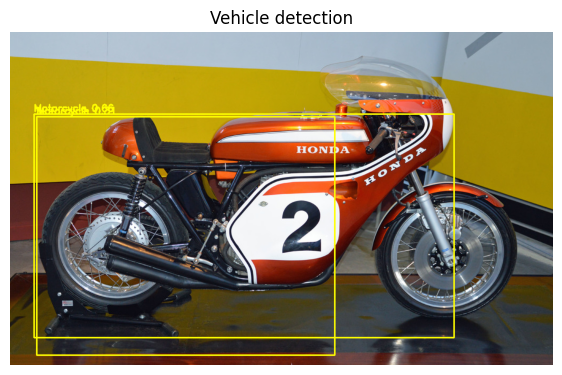

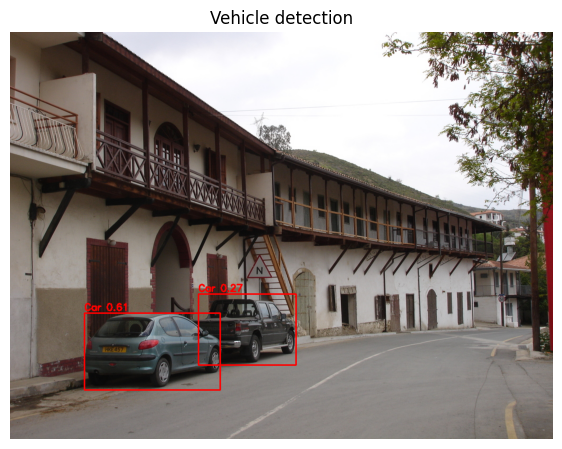

In [ ]:
from ultralytics.utils.plotting import Annotator

# change :3 to a different number to see more outputs
val_imgs = list((project_root/"data"/"yolo_vehicle"/"images"/"val").glob("*.*"))[:3]
names = ['Car','Bus','Truck','Motorcycle']

for p in val_imgs:
    res = vehicle_model.predict(source=str(p), imgsz=640, conf=0.25, verbose=False)[0]

    img = cv2.imread(str(p))  # BGR
    ann = Annotator(img, line_width=2)
    if hasattr(res, "boxes") and res.boxes is not None and len(res.boxes) > 0:
        boxes = res.boxes.xyxy.cpu().numpy()
        clsid = res.boxes.cls.cpu().numpy().astype(int)
        confs = res.boxes.conf.cpu().numpy()

    class_colors = {
        0: (0,0,255),     # Car → Red
        1: (0,255,0),     # Bus → Green
        2: (255,0,0),     # Truck → Blue
        3: (0,255,255)    # Motorcycle → Yellow
    }

    for (x1,y1,x2,y2), c, s in zip(boxes, clsid, confs):
        color = class_colors.get(c, (255,255,255))
        cv2.rectangle(img, (int(x1),int(y1)), (int(x2),int(y2)), color, 2)
        cv2.putText(img, f"{names[c]} {s:.2f}", (int(x1), max(0, int(y1)-5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    img_annotated = ann.result()  # still BGR
    plt.figure(figsize=(7,7))
    plt.imshow(cv2.cvtColor(img_annotated, cv2.COLOR_BGR2RGB))
    plt.title("Vehicle detection")
    plt.axis('off')
    plt.show()

## 7) OCR

Detection finds the plate region, but we still need to read the characters. Here, we use an off-the-shelf OCR (optical character recognition) model to accomplish this.

To improve performance further, we can apply a number of pre-processing steps to the detected license plate before running OCR.

In [ ]:
# === Off-the-shelf OCR: EasyOCR ===
%pip -q install easyocr

import easyocr
import re

# Use GPU if available in Colab
use_gpu = True
reader = easyocr.Reader(['en'], gpu=use_gpu)

# Helper to normalize plate text (A–Z and 0–9 only)
def normalize_plate_text(s: str):
    s = s.upper()
    s = re.sub(r'[^A-Z0-9]', '', s)
    return s

# Optional preprocessing steps
def estimate_skew_angle(gray, delta=1, limit=30):
    """
    Estimate skew angle in degrees using Hough lines on edges.
    Returns angle in [-limit, limit].
    """
    edges = cv2.Canny(gray, 50, 150)
    lines = cv2.HoughLines(edges, 1, np.pi/180, threshold=80)
    if lines is None:
        return 0.0
    angles = []
    for rho, theta in lines[:,0]:
        # Convert to degrees and map near-horizontal lines
        ang = (theta * 180/np.pi) - 90
        # Normalize to [-90, 90]
        if ang < -90: ang += 180
        if ang > 90: ang -= 180
        # keep near horizontal (likely text lines)
        if -limit <= ang <= limit:
            angles.append(ang)
    if not angles:
        return 0.0
    # robust median
    return float(np.median(angles))

def rotate_image_keep_bounds(img, angle_deg):
    if abs(angle_deg) < 0.2:
        return img
    (h, w) = img.shape[:2]
    M = cv2.getRotationMatrix2D((w/2, h/2), angle_deg, 1.0)
    cos = abs(M[0,0]); sin = abs(M[0,1])
    # compute new bounds
    nW = int((h*sin) + (w*cos))
    nH = int((h*cos) + (w*sin))
    # adjust rotation matrix to account for translation
    M[0,2] += (nW/2) - w/2
    M[1,2] += (nH/2) - h/2
    return cv2.warpAffine(img, M, (nW, nH), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)

# Normalize contrast
def clahe_on_luma(bgr):
    # CLAHE on L channel in LAB space
    lab = cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB)
    L, A, B = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    L2 = clahe.apply(L)
    lab2 = cv2.merge([L2, A, B])
    return cv2.cvtColor(lab2, cv2.COLOR_LAB2BGR)

def unsharp_mask(bgr, blur_ksize=0, sigma=1.0, amount=1.0, thresh=0):
    # If blur_ksize==0, use GaussianBlur with sigma
    if blur_ksize <= 0:
        blurred = cv2.GaussianBlur(bgr, (0,0), sigmaX=sigma, sigmaY=sigma)
    else:
        blurred = cv2.GaussianBlur(bgr, (blur_ksize, blur_ksize), 0)
    sharp = cv2.addWeighted(bgr, 1+amount, blurred, -amount, 0)
    if thresh > 0:
        low_contrast_mask = np.absolute(bgr - blurred) < thresh
        np.copyto(sharp, bgr, where=low_contrast_mask)
    return sharp
def preprocess_plate_crop(crop_bgr, target_h=64):
    """
    Preprocess a plate crop for OCR:
    - deskew
    - CLAHE
    - bilateral denoise
    - unsharp
    - upscale to target height
    - pad border
    Returns BGR image (convert to RGB before feeding EasyOCR).
    """
    if crop_bgr is None or crop_bgr.size == 0:
        return crop_bgr

    # 1) mild deskew
    gray = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2GRAY)
    angle = estimate_skew_angle(gray, limit=25)
    deskewed = rotate_image_keep_bounds(crop_bgr, -angle)

    # 2) contrast normalization (CLAHE on luma)
    norm = clahe_on_luma(deskewed)

    # 3) denoise (edge-preserving)
    den = cv2.bilateralFilter(norm, d=5, sigmaColor=50, sigmaSpace=50)

    # 4) sharpen a touch
    sharp = unsharp_mask(den, sigma=1.0, amount=0.6)

    # 5) upscale to fixed height
    h, w = sharp.shape[:2]
    scale = max(1.0, target_h / max(1, h))
    new_w = int(round(w * scale))
    resized = cv2.resize(sharp, (new_w, target_h), interpolation=cv2.INTER_CUBIC)

    # 6) pad a small border (white)
    pad = int(round(0.08 * target_h))
    prepped = cv2.copyMakeBorder(resized, pad, pad, pad, pad,
                                 borderType=cv2.BORDER_CONSTANT, value=(255,255,255))
    return prepped

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

## 8) Plate Detection → OCR

Here, we put everything together:

1. Use the plate detector to find the bounding box of the license plate.

2. Crop the detected region, resize it to the OCR input size (160×48).

3. Run the OCR model to decode the text.

4. Overlay the prediction on the image for visualization.

Try running this cell multiple times to see different sample outputs!

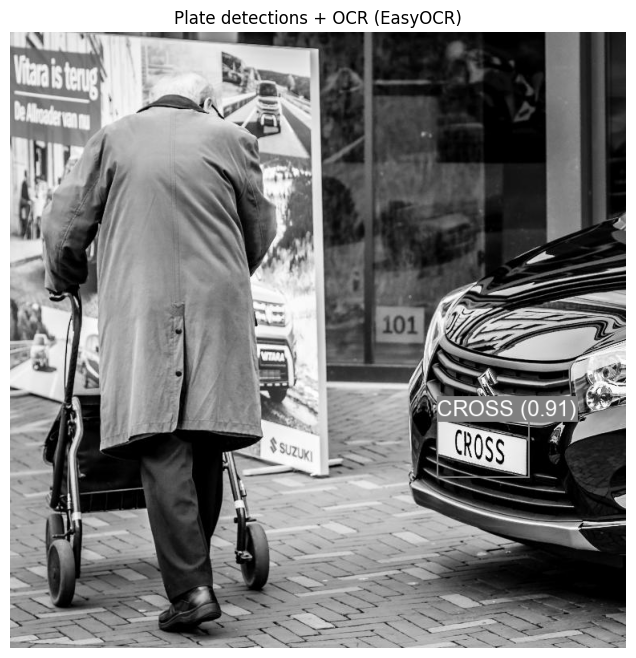

[{'bbox': [532, 484, 647, 555], 'score': 0.9083600640296936, 'text': 'CROSS'}]


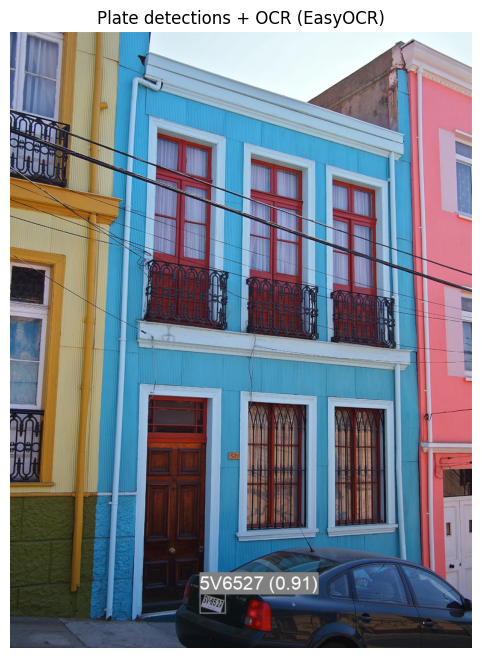

[{'bbox': [315, 933, 358, 966], 'score': 0.9130614995956421, 'text': '5V6527'}]


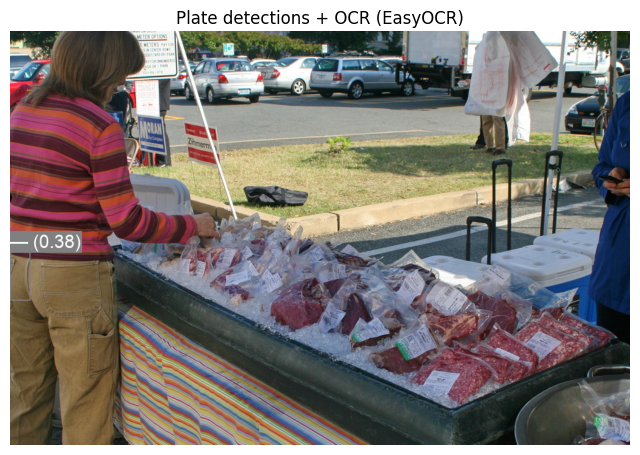

[{'bbox': [0, 364, 33, 444], 'score': 0.37624818086624146, 'text': ''}]


In [ ]:
# === End-to-end inference using YOLO plate detector + EasyOCR ===
from ultralytics.utils.plotting import Annotator
import cv2
import numpy as np
from pathlib import Path

def ocr_easyocr(img_bgr):
    prepped = preprocess_plate_crop(img_bgr, target_h=64)
    # EasyOCR expects RGB
    rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    # detail=0 returns just the strings; you can use detail=1 to also get boxes and confidence
    results = reader.readtext(rgb, detail=1, paragraph=False)
    # Pick the highest-confidence text line, then normalize
    if not results:
        return ""
    # results: list of (bbox, text, conf)
    best = max(results, key=lambda x: x[2])
    text = normalize_plate_text(best[1])
    return text

def detect_and_read(image_path, conf=0.3, visualize=True):
    img = cv2.imread(str(image_path))
    assert img is not None, f"Could not open {image_path}"

    plate_preds = plate_model.predict(source=str(image_path), imgsz=640, conf=conf, verbose=False)[0]
    out = img.copy()
    ann = Annotator(out, line_width=2, pil=True)
    results = []

    if hasattr(plate_preds, "boxes") and plate_preds.boxes is not None and len(plate_preds.boxes) > 0:
        boxes = plate_preds.boxes.xyxy.cpu().numpy()
        confs = plate_preds.boxes.conf.cpu().numpy()

        for (x1,y1,x2,y2), s in zip(boxes, confs):
            x1,y1,x2,y2 = map(int, [x1,y1,x2,y2])
            crop = img[y1:y2, x1:x2]
            if crop.size == 0:
                continue
            text = ocr_easyocr(crop)
            results.append({"bbox":[x1,y1,x2,y2],"score":float(s),"text":text})
            label = f"{text if text else '—'} ({s:.2f})"
            ann.box_label((x1,y1,x2,y2), label=label)

    if visualize:
        rgb = cv2.cvtColor(ann.result(), cv2.COLOR_BGR2RGB)
        import matplotlib.pyplot as plt
        plt.figure(figsize=(8,8)); plt.imshow(rgb); plt.axis('off'); plt.title("Plate detections + OCR (EasyOCR)"); plt.show()

    return results

# Try running multiple times to see different samples
all_imgs = list((project_root/"data"/"yolo_plate"/"images"/"val").glob("*.*"))
test_imgs = random.sample(all_imgs, min(3, len(all_imgs)))
for test_img in test_imgs:
  print(detect_and_read(test_img))